# Plan d.ii -- Descriptive Statistics and Trend Analysis

Characterises ERI, PDI, MDI, inflation, the exchange rate, and FDI (raw and logged) numerically
and visually before any modeling, and answers RQ1 directly: *"How have PDI and MDI trended in
Sri Lanka, 1990-2024?"*

See `docs/2_plan/analysis/ii_descriptive_statistics_and_trend_analysis.md` for the full spec.

**Input** (`outputs/`):
- `analysis_frame_1990_2024.csv` (from step i)

**Outputs** (`outputs/`):
- `descriptive_statistics.csv` -- summary stats table (7 series)
- `correlation_eri_divp_divm.csv` -- light-touch correlation snapshot
- `trend_eri_pdi_mdi_combined.png` -- combined ERI/PDI/MDI chart with shaded shock episodes
- `trend_pdi.png`, `trend_mdi.png` -- individual trend charts, same shading
- RQ1 narrative (markdown, bottom of this notebook), grounded in the numbers computed here

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.transforms import blended_transform_factory

ROOT = Path.cwd().resolve().parents[1]
OUTPUT_DIR = ROOT / "outputs"

FRAME_IN = OUTPUT_DIR / "analysis_frame_1990_2024.csv"

STATS_OUT = OUTPUT_DIR / "descriptive_statistics.csv"
CORR_OUT = OUTPUT_DIR / "correlation_eri_divp_divm.csv"
COMBINED_CHART_OUT = OUTPUT_DIR / "trend_eri_pdi_mdi_combined.png"
PDI_CHART_OUT = OUTPUT_DIR / "trend_pdi.png"
MDI_CHART_OUT = OUTPUT_DIR / "trend_mdi.png"

# Three shock episodes (interpretive grouping of the 5-year SHOCK dummy for visualization only --
# the dummy itself stays as 5 individual years in the regression, step vi). "anchor" controls
# where the label text grows from: the 2020-21 and 2022 bands sit back-to-back, so their labels
# are anchored to opposite outer edges (growing left / right) rather than both centered, which
# would otherwise collide.
SHOCK_EPISODES = [
    {"label": "2008-09 Global Financial Crisis", "start": 2008, "end": 2009, "anchor": "center"},
    {"label": "2020-21 COVID-19 shock", "start": 2020, "end": 2021, "anchor": "left"},
    {"label": "2022 economic/debt crisis", "start": 2022, "end": 2022, "anchor": "right"},
]

# Fixed categorical colors, one series = one color everywhere in this notebook.
COLOR_ERI = "#2a78d6"   # blue
COLOR_PDI = "#008300"   # green
COLOR_MDI = "#eb6834"   # orange
COLOR_SHOCK_BAND = "#898781"
INK_MUTED = "#52514e"

## Step 1 -- Load the analysis frame

In [2]:
frame = pd.read_csv(FRAME_IN)
assert frame.shape[0] == 35, f"expected 35-row analysis frame, got {frame.shape[0]}"
assert frame["shock"].sum() == 5, "SHOCK dummy does not match the 5 flagged years"

print(f"frame: {frame.shape}, years {frame['year'].min()}-{frame['year'].max()}")
frame.head()

frame: (35, 11), years 1990-2024


,year,eri,divp,divm,divp_source,divm_source,inflation_rate_pct,exchange_rate,fdi_net_inflows_usd,log_fdi,shock
0,1990,0.3837,0.794432,0.830069,0.7944,0.8506,21.495250,40.06292,4.335512e+07,17.584935,0
1,1991,0.3678,0.766776,0.811653,0.7668,0.8120,12.185630,41.37150,4.834917e+07,17.693960,0
2,1992,0.3391,0.723811,0.737246,0.7238,0.7372,11.383440,43.82963,1.226258e+08,18.624648,0
3,1993,0.5452,0.719521,0.737053,0.7195,0.7371,11.746740,48.32217,1.944791e+08,19.085835,0
4,1994,0.6214,0.731781,0.729237,0.7318,0.7385,8.448712,49.41514,1.664129e+08,18.929983,0


## Step 2 -- Summary statistics table

N, mean, sample standard deviation (`n-1` denominator), min, max, median, skewness, and excess
kurtosis for `ERI, DIVP, DIVM, INF, EXR, FDI (raw), log(FDI)`.

**Convention used:** `pandas.Series.skew()` / `.kurt()` -- the adjusted Fisher-Pearson
(bias-corrected) standardized moment estimators, equivalent to `scipy.stats.skew(bias=False)` /
`scipy.stats.kurtosis(bias=False, fisher=True)` (excess kurtosis, i.e. normal = 0). EViews'
default `@skew`/`@kurt` use the biased (population-moment) convention, which differs slightly
from the values reported here -- flagged for reproducibility, not resolved.

In [3]:
VARIABLES = {
    "ERI": "eri",
    "DIVP": "divp",
    "DIVM": "divm",
    "INF": "inflation_rate_pct",
    "EXR": "exchange_rate",
    "FDI (raw)": "fdi_net_inflows_usd",
    "log(FDI)": "log_fdi",
}


def _describe(series: pd.Series, label: str) -> dict:
    return {
        "variable": label,
        "n": series.count(),
        "mean": series.mean(),
        "std_dev": series.std(ddof=1),
        "min": series.min(),
        "max": series.max(),
        "median": series.median(),
        "skewness": series.skew(),
        "excess_kurtosis": series.kurt(),
    }


stats_table = pd.DataFrame(
    [_describe(frame[col], label) for label, col in VARIABLES.items()]
)
stats_table.to_csv(STATS_OUT, index=False)
print(f"Written -> {STATS_OUT}")
stats_table

Written -> /Users/mohamedinas/Desktop/SE_projects/11_fathima_research/1_eda_and_modeling/8_interview_prep/outputs/descriptive_statistics.csv


,variable,n,mean,std_dev,min,max,median,skewness,excess_kurtosis
0,ERI,35,6.198629e-01,1.706780e-01,3.391000e-01,9.667000e-01,6.242000e-01,0.189970,-0.581613
1,DIVP,35,7.402823e-01,4.205120e-02,6.453463e-01,7.999229e-01,7.552528e-01,-0.674579,-0.338383
2,DIVM,35,7.933352e-01,3.147510e-02,6.945383e-01,8.300694e-01,7.994120e-01,-1.339287,1.828130
3,INF,35,1.002186e+01,8.619310e+00,-4.293600e-01,4.972110e+01,7.674849e+00,3.084981,12.974141
4,EXR,35,1.212427e+02,7.416630e+01,4.006292e+01,3.275065e+02,1.083338e+02,1.547731,2.332144
5,FDI (raw),35,5.130693e+08,3.894631e+08,4.335512e+07,1.614044e+09,4.340757e+08,0.892376,0.498509
6,log(FDI),35,1.969909e+01,9.500258e-01,1.758494e+01,2.120201e+01,1.988873e+01,-0.585290,-0.398853


## Step 3 -- Combined ERI/PDI/MDI trend chart, 1990-2024

ERI, PDI, and MDI are each bounded roughly 0-1 (confirmed below), so they are visually
comparable on a single axis -- no secondary axis needed. Shock episodes are shaded as three
bands (not five individual year-slivers) and labeled.

In [4]:
range_check = frame[["eri", "divp", "divm"]].agg(["min", "max"])
print("Range check (all three series, confirms single-axis comparability):")
print(range_check)
assert range_check.loc["min"].min() >= 0 and range_check.loc["max"].max() <= 1, (
    "one of ERI/DIVP/DIVM falls outside [0, 1] -- combined single-axis chart assumption violated"
)

Range check (all three series, confirms single-axis comparability):
        eri      divp      divm
min  0.3391  0.645346  0.694538
max  0.9667  0.799923  0.830069


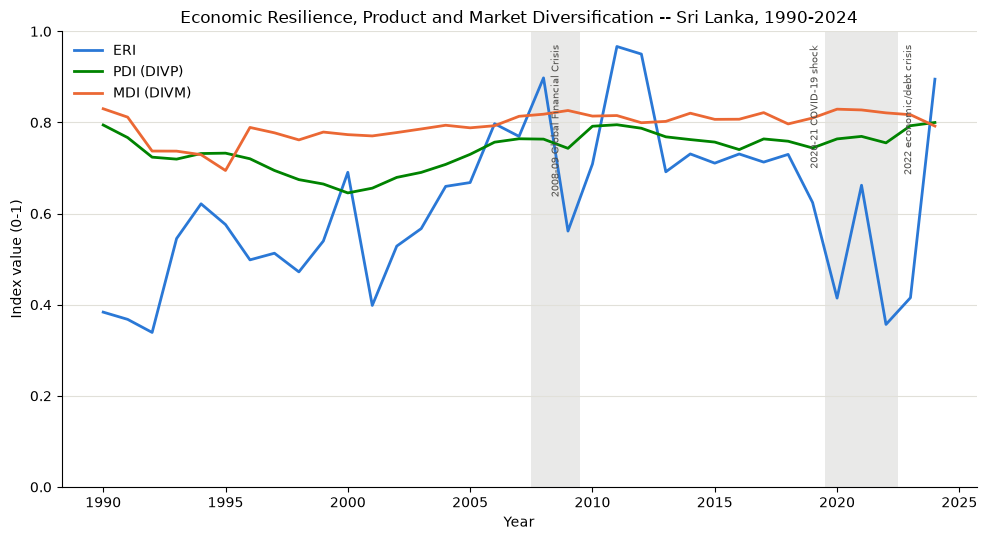

Written -> /Users/mohamedinas/Desktop/SE_projects/11_fathima_research/1_eda_and_modeling/8_interview_prep/outputs/trend_eri_pdi_mdi_combined.png


In [5]:
def _shade_shock_episodes(ax, label_y=0.97):
    label_transform = blended_transform_factory(ax.transData, ax.transAxes)
    for episode in SHOCK_EPISODES:
        start, end = episode["start"], episode["end"]
        ax.axvspan(start - 0.5, end + 0.5, color=COLOR_SHOCK_BAND, alpha=0.18, zorder=0, lw=0)
        if episode["anchor"] == "left":
            x, ha = start - 0.7, "right"
        elif episode["anchor"] == "right":
            x, ha = end + 0.7, "left"
        else:
            x, ha = (start + end) / 2, "center"
        va = "top" if label_y > 0.5 else "bottom"
        ax.text(
            x, label_y, episode["label"],
            transform=label_transform, ha=ha, va=va,
            fontsize=7.5, color=INK_MUTED, rotation=90,
        )


fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(frame["year"], frame["eri"], color=COLOR_ERI, lw=2, label="ERI")
ax.plot(frame["year"], frame["divp"], color=COLOR_PDI, lw=2, label="PDI (DIVP)")
ax.plot(frame["year"], frame["divm"], color=COLOR_MDI, lw=2, label="MDI (DIVM)")
_shade_shock_episodes(ax)

ax.set_title("Economic Resilience, Product and Market Diversification -- Sri Lanka, 1990-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Index value (0-1)")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", lw=0.8, zorder=-1)
ax.legend(loc="upper left", frameon=False)

fig.tight_layout()
fig.savefig(COMBINED_CHART_OUT, dpi=150)
plt.show()
print(f"Written -> {COMBINED_CHART_OUT}")

## Step 4 -- Individual PDI and MDI trend charts

Single-series charts are cleaner for spotting structural breaks than the combined chart above;
same three shaded shock bands.

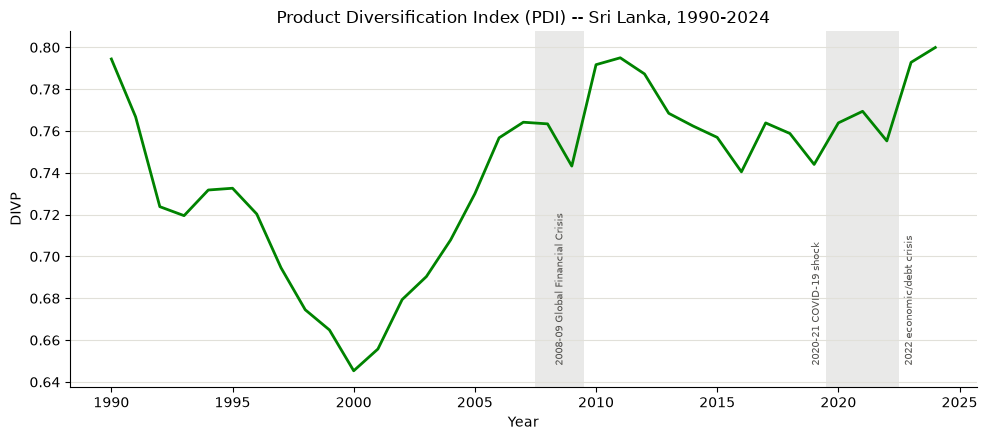

Written -> /Users/mohamedinas/Desktop/SE_projects/11_fathima_research/1_eda_and_modeling/8_interview_prep/outputs/trend_pdi.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(frame["year"], frame["divp"], color=COLOR_PDI, lw=2)
_shade_shock_episodes(ax, label_y=0.06)

ax.set_title("Product Diversification Index (PDI) -- Sri Lanka, 1990-2024")
ax.set_xlabel("Year")
ax.set_ylabel("DIVP")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", lw=0.8, zorder=-1)

fig.tight_layout()
fig.savefig(PDI_CHART_OUT, dpi=150)
plt.show()
print(f"Written -> {PDI_CHART_OUT}")

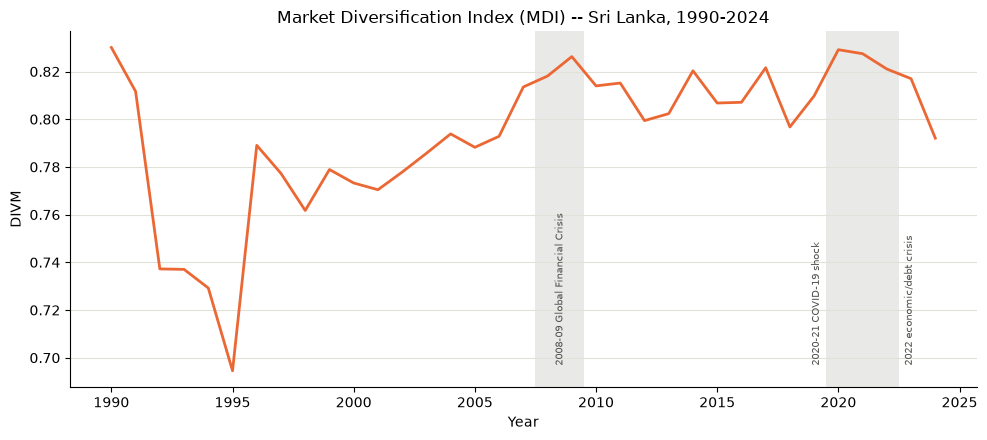

Written -> /Users/mohamedinas/Desktop/SE_projects/11_fathima_research/1_eda_and_modeling/8_interview_prep/outputs/trend_mdi.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(frame["year"], frame["divm"], color=COLOR_MDI, lw=2)
_shade_shock_episodes(ax, label_y=0.06)

ax.set_title("Market Diversification Index (MDI) -- Sri Lanka, 1990-2024")
ax.set_xlabel("Year")
ax.set_ylabel("DIVM")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", lw=0.8, zorder=-1)

fig.tight_layout()
fig.savefig(MDI_CHART_OUT, dpi=150)
plt.show()
print(f"Written -> {MDI_CHART_OUT}")

## Step 5 -- Correlation snapshot (optional, light-touch)

A simple pairwise correlation matrix among ERI, DIVP, DIVM, as a companion to the trend
narrative below. This is *not* the regressor correlation matrix required for VIF cross-checking
in step iv -- that stays scoped to step iv, not here.

In [8]:
corr_matrix = frame[["eri", "divp", "divm"]].corr()
corr_matrix.to_csv(CORR_OUT)
print(f"Written -> {CORR_OUT}")
corr_matrix

Written -> /Users/mohamedinas/Desktop/SE_projects/11_fathima_research/1_eda_and_modeling/8_interview_prep/outputs/correlation_eri_divp_divm.csv


,eri,divp,divm
eri,1.000000,0.363529,0.189419
divp,0.363529,1.000000,0.533963
divm,0.189419,0.533963,1.000000


## Step 6 -- Supporting figures for the narrative

Pulls out the specific numbers the RQ1 narrative below is grounded in: how often MDI exceeds
PDI, start/end/min/max levels, linear trend slopes, and behaviour around the shock episodes.

In [9]:
mdi_above_pdi_share = (frame["divm"] > frame["divp"]).mean()
exception_years = frame.loc[frame["divp"] >= frame["divm"], "year"].tolist()

slopes = {
    col: np.polyfit(frame["year"], frame[col], 1)[0]
    for col in ["eri", "divp", "divm"]
}

endpoints = frame.set_index("year")[["eri", "divp", "divm"]].loc[[1990, 2024]]

extrema = {
    col: {
        "min_year": int(frame.loc[frame[col].idxmin(), "year"]),
        "min": frame[col].min(),
        "max_year": int(frame.loc[frame[col].idxmax(), "year"]),
        "max": frame[col].max(),
    }
    for col in ["eri", "divp", "divm"]
}

print(f"MDI > PDI in {mdi_above_pdi_share:.1%} of years; exceptions: {exception_years}")
print(f"Linear trend slopes (index pts/yr): {slopes}")
print("1990 vs 2024 levels:")
print(endpoints)
print("Extrema:")
for col, vals in extrema.items():
    print(f"  {col}: min {vals['min']:.4f} ({vals['min_year']}), max {vals['max']:.4f} ({vals['max_year']})")
print()
print("Around the 2022 debt-crisis / IMF-program window:")
print(frame[frame["year"].between(2018, 2024)][["year", "eri", "divp", "divm"]].to_string(index=False))
print()
print("Around the 2008-09 GFC window:")
print(frame[frame["year"].between(2006, 2011)][["year", "eri", "divp", "divm"]].to_string(index=False))

MDI > PDI in 91.4% of years; exceptions: [1994, 1995, 2024]
Linear trend slopes (index pts/yr): {'eri': np.float64(0.006518571428571471), 'divp': np.float64(0.0020779303256355038), 'divm': np.float64(0.001879834659630494)}
1990 vs 2024 levels:
         eri      divp      divm
year                            
1990  0.3837  0.794432  0.830069
2024  0.8950  0.799923  0.792059
Extrema:
  eri: min 0.3391 (1992), max 0.9667 (2011)
  divp: min 0.6453 (2000), max 0.7999 (2024)
  divm: min 0.6945 (1995), max 0.8301 (1990)

Around the 2022 debt-crisis / IMF-program window:
 year    eri     divp     divm
 2018 0.7299 0.758811 0.796762
 2019 0.6242 0.744014 0.809771
 2020 0.4145 0.763879 0.829151
 2021 0.6622 0.769416 0.827465
 2022 0.3567 0.755253 0.821047
 2023 0.4154 0.792818 0.816997
 2024 0.8950 0.799923 0.792059

Around the 2008-09 GFC window:
 year    eri     divp     divm
 2006 0.7972 0.756737 0.792847
 2007 0.7694 0.764191 0.813526
 2008 0.8978 0.763408 0.818106
 2009 0.5616 0.743224 0.82

## RQ1 -- How have PDI and MDI trended in Sri Lanka, 1990-2024?

**Is MDI consistently higher than PDI?** Yes, with three exceptions. MDI exceeds PDI in 32 of
the 35 sample years (91%); the exceptions are 1994, 1995, and 2024. The mean level over the
full sample is 0.793 for DIVM versus 0.740 for DIVP, so export markets have been more
diversified than export products for almost the entire period -- with 2024 the one recent year
where product diversification pulled ahead of market diversification (DIVP 0.800 vs DIVM
0.792).

**Overall direction, 1990 to 2024.** Both indices drift mildly upward over the full sample but
are essentially flat-to-slowly-rising rather than trending strongly in either direction: DIVP
rises from 0.794 (1990) to 0.800 (2024), a fitted linear slope of only +0.0021 index points/year,
after dipping to a sample low of 0.645 in 2000. DIVM starts higher, at 0.830 in 1990, falls to a
sample low of 0.695 in 1995, and recovers to 0.792 by 2024 (slope +0.0019/year) -- so its 2024
level is actually just below where it started 34 years earlier. Neither series is
regime-shifting; both spend the sample oscillating within a relatively narrow high band
(roughly 0.65-0.83) rather than showing a clean secular trend. ERI, by contrast, is far more
volatile (std. dev. 0.171 vs. 0.042 for DIVP and 0.031 for DIVM) and spans nearly the full
0-1 range (0.339 in 1992 to 0.967 in 2011), with a much steeper fitted slope of +0.0065/year.

**Visible break around 2022?** ERI shows a sharp, visually obvious dip in the 2022 debt-crisis /
IMF-program year (0.357, its second-lowest value in the sample, alongside a similar dip to 0.415
in 2020 and 0.365 -- 2009's 0.562 during the GFC) -- flagged here as a visual/descriptive
observation only, not a formally tested structural break. PDI and MDI do **not** show a
comparable break in 2022: DIVP (0.755) and DIVM (0.821) both sit within their normal
mid-2010s-to-2020s range that year, and DIVP continues rising through 2023-2024 to its
sample maximum. In other words, the 2022 crisis is visually striking in the resilience index but
barely visible in either diversification index.

**How does ERI move relative to PDI/MDI?** Weakly and inconsistently. The pairwise correlations
are low: ERI-DIVP is 0.36, ERI-DIVM is only 0.19, while DIVP-DIVM (0.53) is the strongest of the
three pairs. ERI reacts sharply to each shock episode (dipping in 2009, 2020, and 2022) and then
rebounds quickly (e.g. to a sample-high 0.967 in 2011, and to 0.895 by 2024), while PDI and MDI
move on a slower, much less shock-sensitive path. This weak raw correlation is exactly why the
RQ2 regression (step vi) needs a proper multivariate specification, controlling for inflation,
the exchange rate, and FDI, rather than relying on the simple bivariate association shown here.

*Candidate follow-up (out of scope for d.ii):* the 2022 ERI dip looks like it could be a genuine
structural break rather than ordinary volatility; a formal break test (e.g. Chow or Bai-Perron)
would be worth flagging for a later step if the thesis wants to substantiate that claim
statistically.